In [9]:
# Blink detection CNN (open vs closed eyes) - local dataset
# Dataset: C:\Users\hp\Downloads\archive\mrleyedataset
#   Open-Eyes  -> open
#   Close-Eyes -> closed
# Train/val split is done inside Keras (80% / 20%).

from pathlib import Path

DATASET_DIR = Path(r"C:\Users\hp\Downloads\archive\mrleyedataset")
OPEN_DIR = DATASET_DIR / "Open-Eyes"
CLOSED_DIR = DATASET_DIR / "Close-Eyes"

print("Dataset folder:", DATASET_DIR)
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Not found: {DATASET_DIR}")
if not OPEN_DIR.exists() or not CLOSED_DIR.exists():
    raise FileNotFoundError("Need folders 'Open-Eyes' and 'Close-Eyes'.")

print("Open-Eyes images :", len(list(OPEN_DIR.glob('*'))))
print("Close-Eyes images:", len(list(CLOSED_DIR.glob('*'))))
print("OK - paths look good. Run next cell for imports and training.")


Dataset folder: C:\Users\hp\Downloads\archive\mrleyedataset
Open-Eyes images : 42952
Close-Eyes images: 41928
OK - paths look good. Run next cell for imports and training.


In [10]:
# Imports and TensorFlow version (needs: pip install tensorflow matplotlib scikit-learn seaborn)
import os
import numpy as np
import matplotlib.pyplot as plt

# Use standalone keras imports so type checkers recognize layers/models (avoids tf.keras stub gaps)
import tensorflow as tf  # still used for tf.data and backend
import keras
from keras import layers, models

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("Keras version:     ", keras.__version__)


TensorFlow version: 2.21.0
Keras version:      3.14.0


In [11]:
# Load images: 64x64, binary labels, internal 80/20 split
DATASET_DIR_STR = str(DATASET_DIR)
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

train_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR_STR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR_STR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False,
)

# Class order matches Keras: subfolder names sorted (e.g. Close-Eyes=0, Open-Eyes=1)
from pathlib import Path

raw_class_names = sorted(
    p.name for p in Path(DATASET_DIR_STR).iterdir() if p.is_dir()
)
display_class_names = ["closed", "open"]
print("Keras class order (folders):", raw_class_names)
print("Plots will use labels:", display_class_names)


Found 84880 files belonging to 2 classes.
Using 67904 files for training.
Found 84880 files belonging to 2 classes.
Using 16976 files for validation.
Keras class order (folders): ['Close-Eyes', 'Open-Eyes']
Plots will use labels: ['closed', 'open']


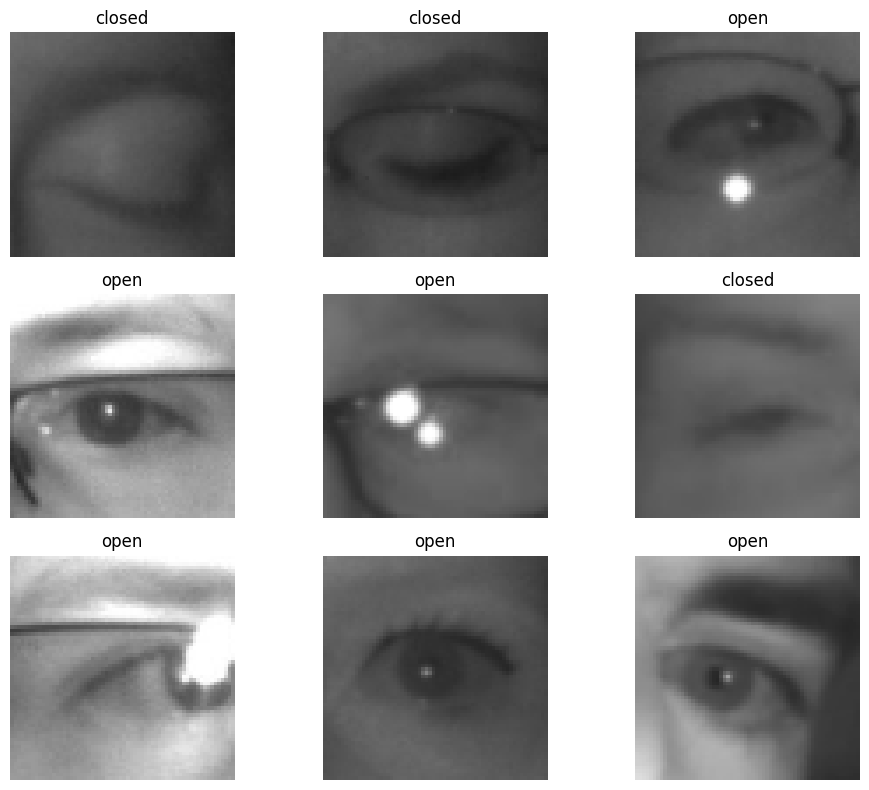

In [12]:
# Normalize [0,255] -> [0,1], prefetch, show 9 sample images
# Keras stubs may type datasets as list; cast so .map() is valid for the checker
from typing import cast

normalization_layer = layers.Rescaling(1.0 / 255)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = cast(tf.data.Dataset, train_ds).map(
    lambda x, y: (normalization_layer(x), y)
).cache().prefetch(AUTOTUNE)
val_ds = cast(tf.data.Dataset, val_ds).map(
    lambda x, y: (normalization_layer(x), y)
).cache().prefetch(AUTOTUNE)

plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_class_names[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [13]:
# CNN from scratch (no pre-trained weights); sigmoid for binary output
model = models.Sequential(
    [
        layers.Input(shape=(64, 64, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train (5-8 epochs - change EPOCHS if you want faster demo)
EPOCHS = 8
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Epoch 1/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.9454 - loss: 0.1469 - val_accuracy: 0.9909 - val_loss: 0.0252
Epoch 2/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 63s 30ms/step - accuracy: 0.9773 - loss: 0.0651 - val_accuracy: 0.9932 - val_loss: 0.0167
Epoch 3/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 52s 25ms/step - accuracy: 0.9829 - loss: 0.0497 - val_accuracy: 0.9946 - val_loss: 0.0159
Epoch 4/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.9846 - loss: 0.0424 - val_accuracy: 0.9959 - val_loss: 0.0126
Epoch 5/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9867 - loss: 0.0382 - val_accuracy: 0.9962 - val_loss: 0.0135
Epoch 6/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9882 - loss: 0.0331 - val_accuracy: 0.9963 - val_loss: 0.0118
Epoch 7/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - accuracy: 0.9888 - loss: 0.0314 - val_accuracy: 0.9948 - val_loss: 0.0179
Epoch 8/8
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 52s 25ms/step - accuracy: 0.9900 - loss: 0

In [15]:
# Final validation loss and accuracy
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Final validation accuracy: {val_acc:.4f}")
print(f"Final validation loss:     {val_loss:.4f}")


Final validation accuracy: 0.9946
Final validation loss:     0.0171


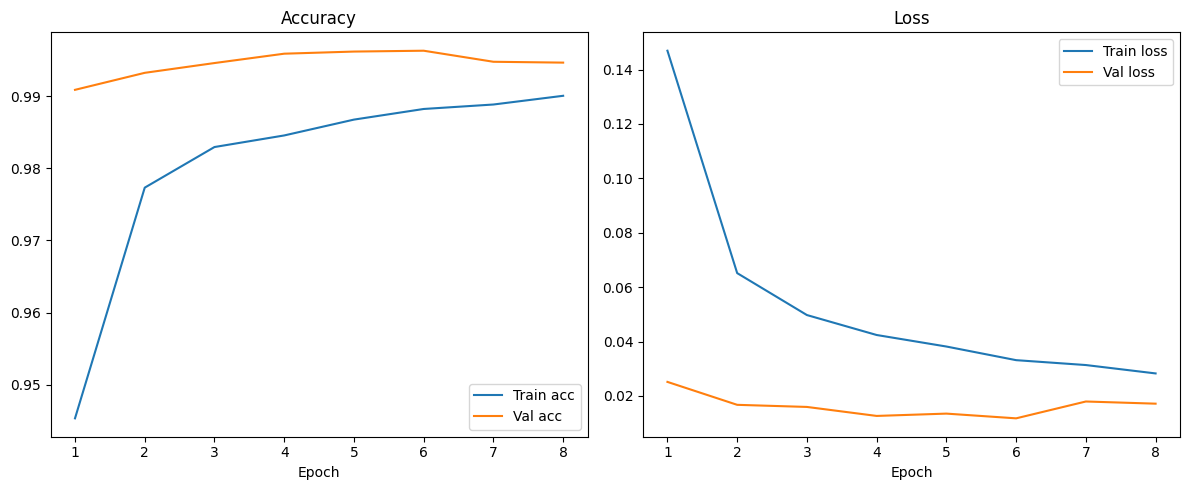

In [16]:
# Accuracy and loss curves vs epoch
acc = history.history["accuracy"]
val_acc_hist = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss_hist = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train acc")
plt.plot(epochs_range, val_acc_hist, label="Val acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train loss")
plt.plot(epochs_range, val_loss_hist, label="Val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()


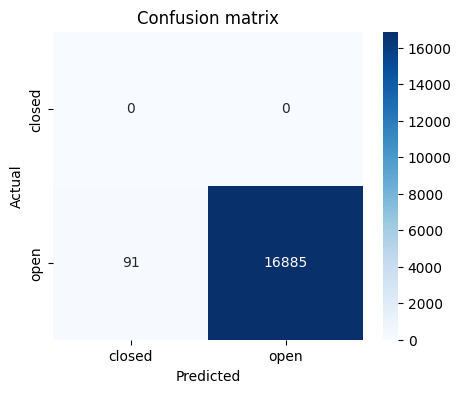


Classification report:
              precision    recall  f1-score   support

      closed       0.00      0.00      0.00         0
        open       1.00      0.99      1.00     16976

    accuracy                           0.99     16976
   macro avg       0.50      0.50      0.50     16976
weighted avg       1.00      0.99      1.00     16976



c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [17]:
# Confusion matrix + classification report on validation set
from typing import Any

y_true = []
y_pred = []

# Keras/TF datasets are runtime-iterable but stubs use ObjectProxy / non-iterable types
val_batches: Any = val_ds
for images, labels in val_batches:
    preds = model.predict_on_batch(images)
    preds = (preds > 0.5).astype("int32").flatten()
    y_pred.extend(preds.tolist())
    y_true.extend(labels.numpy().astype("int32").flatten().tolist())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
ax.set_xticklabels(display_class_names)
ax.set_yticklabels(display_class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=display_class_names))


In [18]:
# Save next to notebook / cwd so main.py finds it (same folder as main.py if you run from project root)
from pathlib import Path

_out = (Path.cwd() / "eye_model.h5").resolve()
model.save(str(_out))
print("Saved:", _out)
print("Run main.py from this project or copy eye_model.h5 beside main.py")


Saved: D:\DL mini project\eye_model.h5
Run main.py from this project or copy eye_model.h5 beside main.py
